# Separação para os dados de teste

## 1. Importação das bibliotecas

Para o treinamento adequado do modelo, é necessário usar a biblioteca sckit-learn para auxiliar no aprendizado de máquina, importando funções de métricas, seleção de dados para o treinamento e no modelo utilizado. Além disso, utilizou-se o pandas para manipulação do dataframe.

In [111]:
from sklearn.metrics import recall_score, f1_score, precision_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

## 2. Teste do modelo árvore de decisão

Uma árvore de decisão é um modelo visual e hierárquico, semelhante a um fluxograma, representando um processo de decisão, mostrando as etapas, escolhas e decisões.

### 2.1. Função geral para realizar as predições

Para facilitar a visualização das métricas do modelo, realizou-se a seguinte função para realizar isso:

In [112]:
def prediction_metrics(archive):
    # Leitura e preparação do dataframe
    df = pd.read_csv(archive)
    df["TempoQ3"] = df["TempoQ3"].fillna(df["TempoQ3"].mean())
    X = df.copy()
    X = X.drop("Oficinas", axis = 1)
    X = X.drop("Aprovou_Aprovou", axis = 1)

    # Preparação da label para realizar a predição
    y = df["Aprovou_Aprovou"]

    features_names = X.columns.tolist()

    # Separação dos dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify=y)

    # Configuração do GridSearch
    # Dicionário com os parâmetros de grid
    param_grid = {
        'criterion': ['gini', 'entropy'], # Medição da quantidade de um divisão ('gini' e 'entropy')
        'max_depth': [None, 5, 10, 15, 20], # Profundidade da árvore
        'min_samples_leaf': [1, 5, 10, 20] # O número mínimos de amostras que uma "folha" deve ter
    }

    # Criação de scorer para ser utilizado no grid search
    f1_score_reprovou = make_scorer(f1_score, pos_label=0)

    # Instanciação do gridSearch
    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        scoring=f1_score_reprovou,
        cv=5, # Indica em quanta partes os dados de treino foram divididos para comparar os resultados 
        n_jobs=-1, # Define quantos núcleos serão direcionados para realizar a tarefa, -1 usar quantos estiverem disponíveis
        verbose=1 # Nível de detalhes que será exibido na execução do grid search
    )

    # Treinamento do modelo usando gridSearch
    print("\nIniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...")
    grid_search.fit(X_train, y_train)

    # Análise dos resultados obtidos
    print("\nMelhores parâmetros encontrados:")
    print(grid_search.best_params_)

    # Escolher o melhor modelo
    best_model = grid_search.best_estimator_

    # Plotar a árvore
    print("\nPlotando a árvore de decisão...")
    plt.figure(figsize=(25, 15))

    fig = plot_tree(
        best_model,
        feature_names=features_names,
        class_names=['Reprovou', 'Aprovou'],
        filled=True,
        rounded=True,
        fontsize=10
    )

    plt.title("Melhor árvore de decisão encontrada pelo GridSearchCV")
    plt.show()

    # Realizar a predição
    y_pred = best_model.predict(X_test)

    # Definição e execução do modelo sem o gridSearch
    # model = DecisionTreeClassifier()
    # model.fit(X_train, y_train)
    # y_pred = model.predict(X_test)

    # Métricas obtidas:
    print("\n--- Métricas obtidas ---")
    recall = recall_score(y_test, y_pred, pos_label=0)
    print(f"Recall: {recall}")

    precision = precision_score(y_test, y_pred, pos_label=0)
    print(f"Precisão: {precision}")

    f1score = f1_score(y_test, y_pred, pos_label=0)
    print(f"F1 Score: {f1score}")


### 2.1.1. Teste com o dataframe completo

Primeiro teste do modelo de árvore de decisão com o dataframe completo


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5}

Plotando a árvore de decisão...


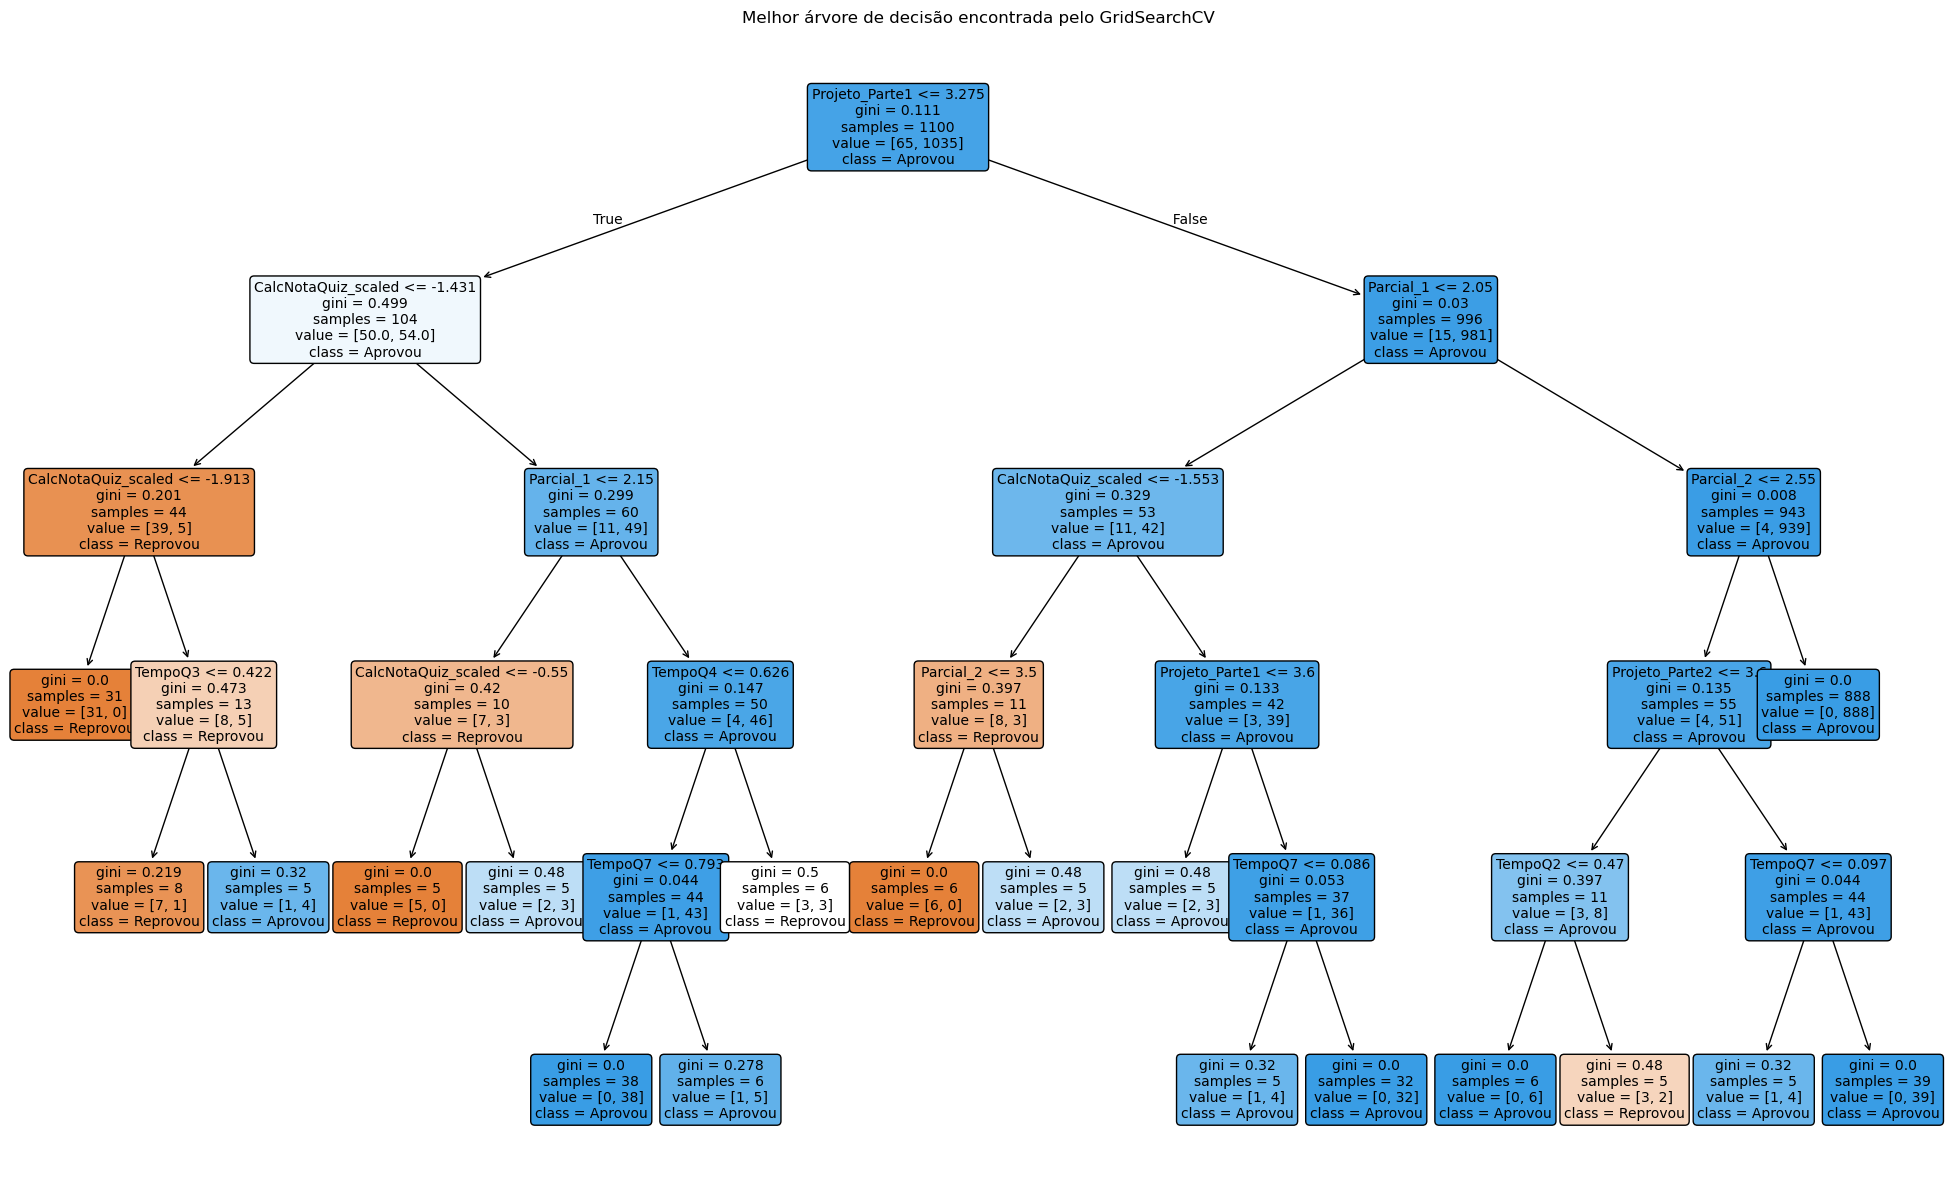


--- Métricas obtidas ---
Recall: 0.6875
Precisão: 0.7333333333333333
F1 Score: 0.7096774193548387


In [113]:
# Para evitar uma mensagem de erro desnecessária, ocasionado pelo ResourceTracker, utiliza-se o seguinte condicional que será repetido nos próximos datasets
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo.csv")

### 2.1.2. Teste com o dataframe da semana 4

Segundo teste com os dados referentes à primeira predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}

Plotando a árvore de decisão...


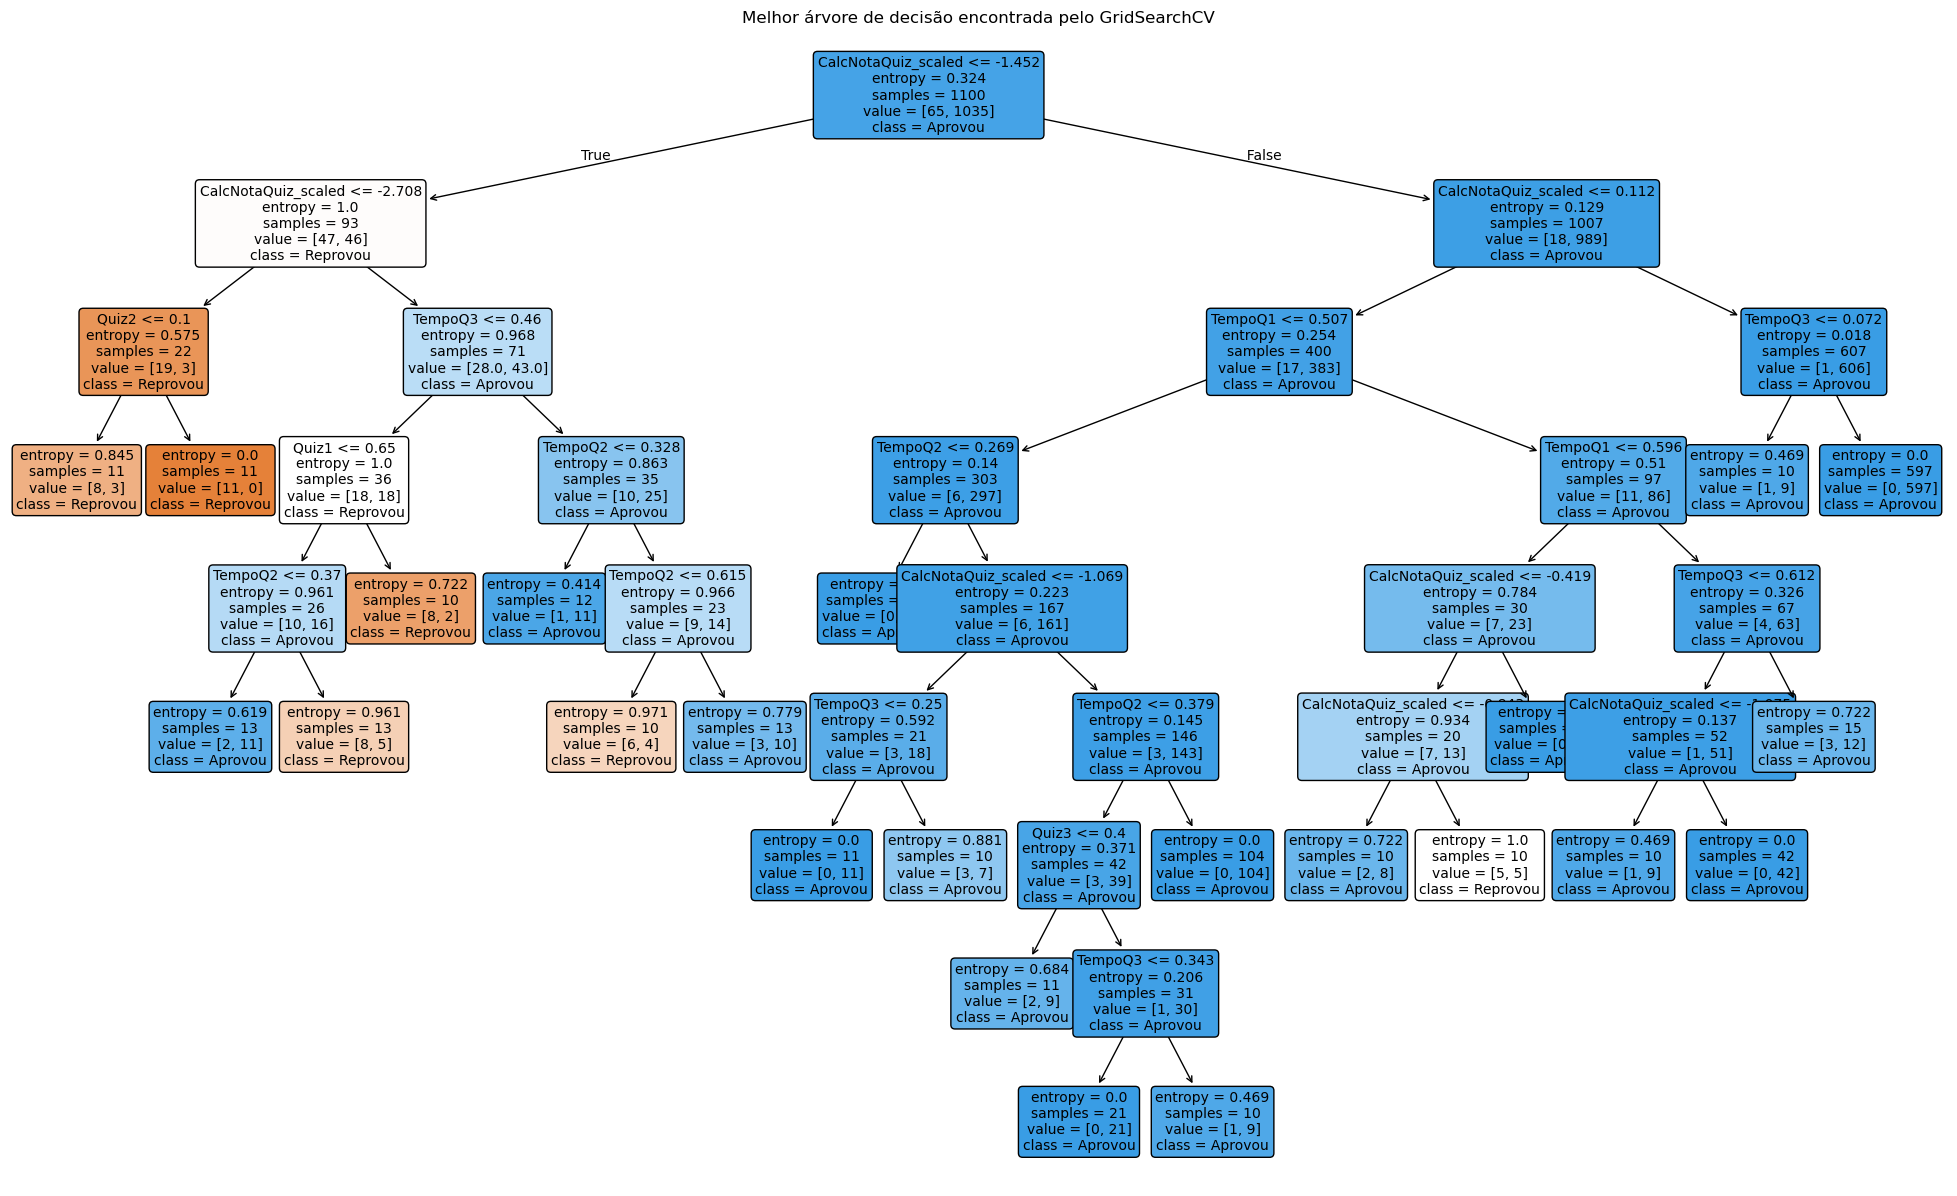


--- Métricas obtidas ---
Recall: 0.5
Precisão: 0.3076923076923077
F1 Score: 0.38095238095238093


In [114]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo1.csv")

### 2.1.3 Teste com o dataframe da semana 8

Terceiro teste com os dados referentes à segunda predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 20}

Plotando a árvore de decisão...


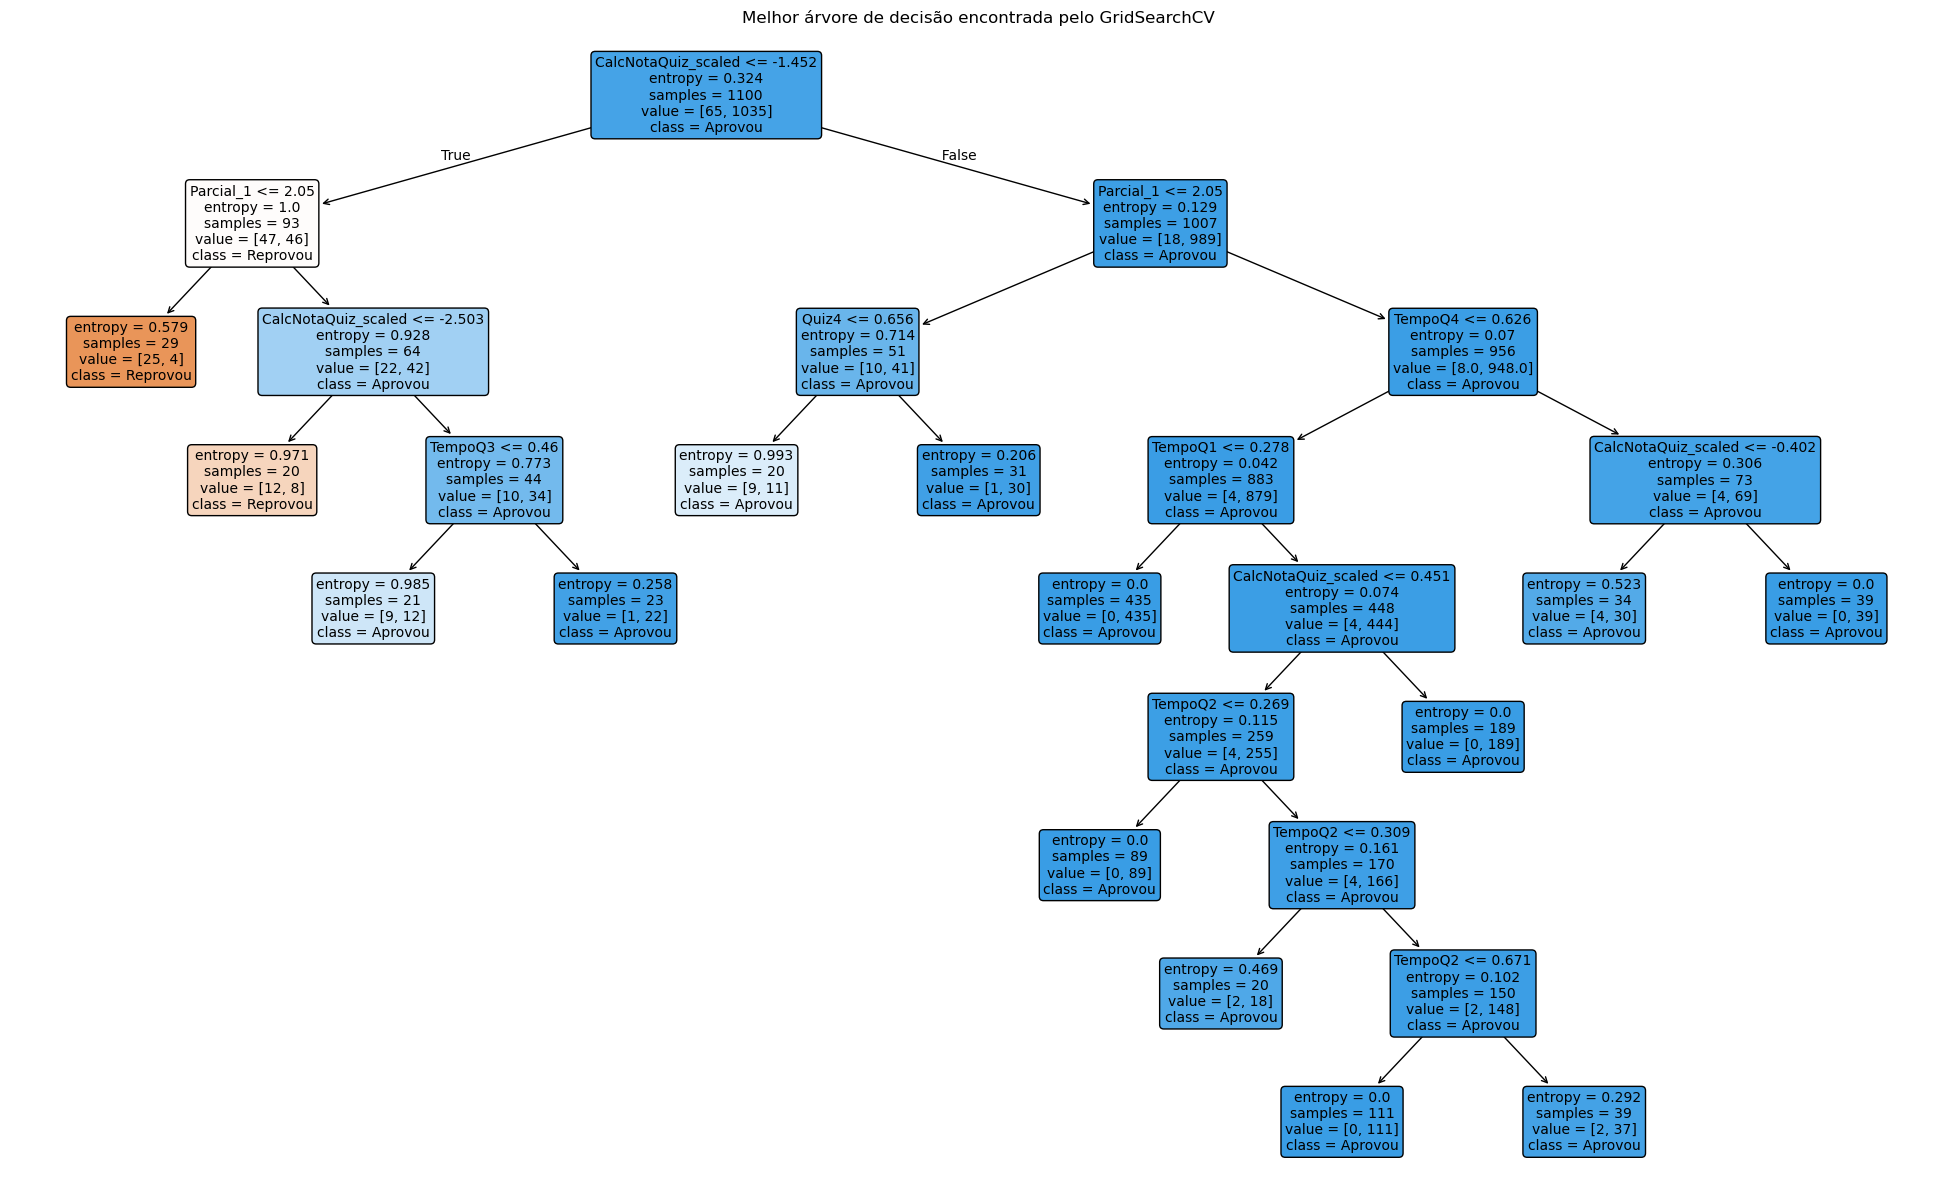


--- Métricas obtidas ---
Recall: 0.5625
Precisão: 0.5
F1 Score: 0.5294117647058824


In [115]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo2.csv")

### 2.1.4 Teste com o dataframe da semana 12

Quarto teste com os dados referentes à terceira predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 20}

Plotando a árvore de decisão...


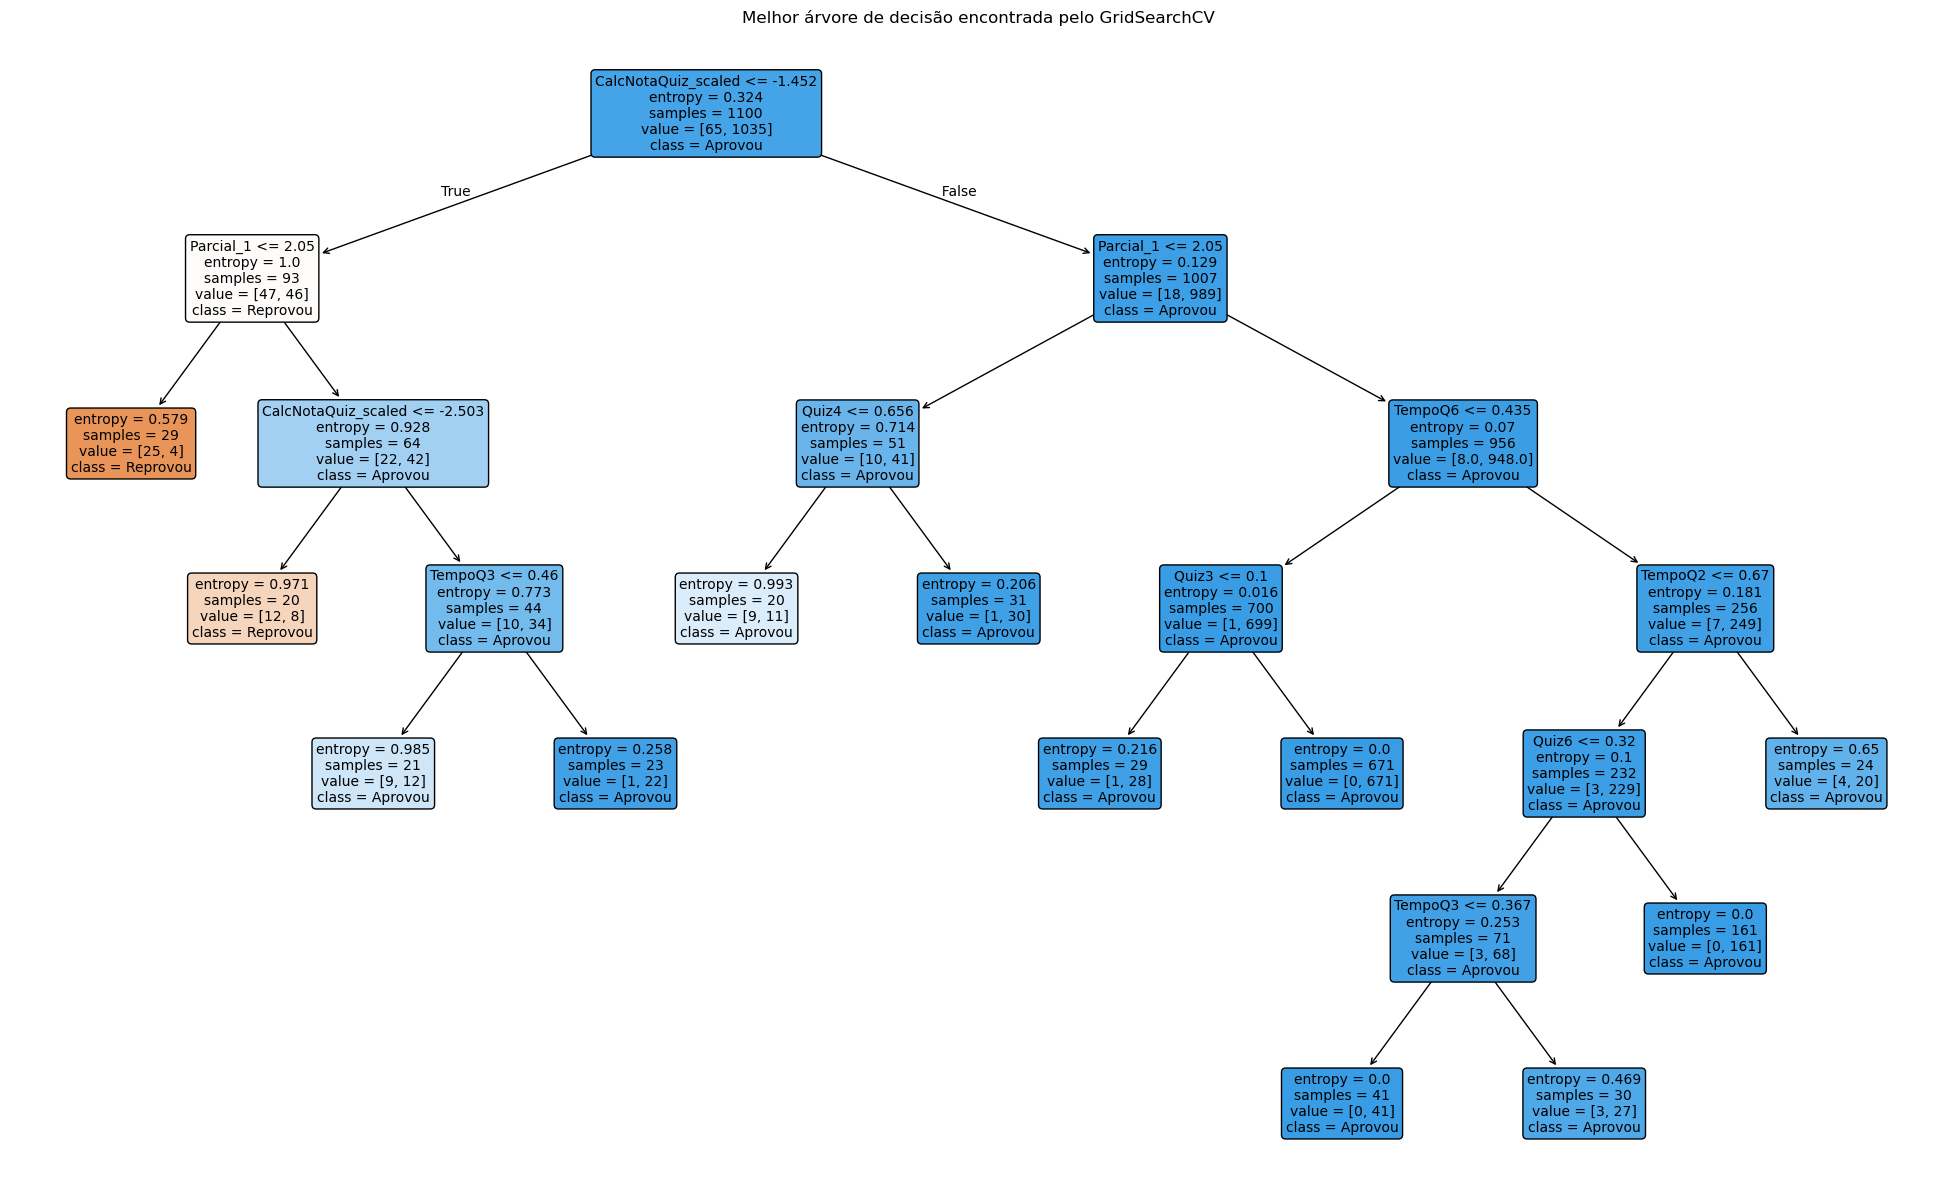


--- Métricas obtidas ---
Recall: 0.5625
Precisão: 0.5
F1 Score: 0.5294117647058824


In [116]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo3.csv")

## 3. Conclusões

Observa-se que as métricas e árvore de decisão feitas nos datasets das semanas 8 e 12 são as mesmas. Portanto, segundo o modelo árvore de decisão, qualquer dado adicional após a semana 8 é desnecessário, isso ocorre devido ao aluno está em um estado quase irreversível de reprovação. Para evitar isso, deve-se propor uma medida de intervenção antes da semana 8 para ajudar o aluno. 